# AFL Data Foundations: EDA, Feature Engineering & Prediction Targets
**Week goal:** deeply understand the AFL dataset, define prediction targets precisely,  
engineer leakage-free features, and create reproducible train/hold-out splits.

**Files:**
- `afl_comb_CLdata.csv`: season-level aggregated player stats (player-season grain)
- `players_round_by_round_clean.csv`: player-game stats every round (player-game grain)
- `rbr_H_A_merged.csv`: player-game stats with home/away, venue, crowd added

**Primary key links:** `player_id` (player), `team` + `match_date` (match), `year` (season)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

OUT = "."   # output directory for saved files
print("Imports OK")

Imports OK


## Task 1: Data Inventory & Understanding

In [ ]:
# Load all three tables 
comb = pd.read_csv("afl_comb_CLdata.csv", low_memory=False)
rbr  = pd.read_csv("players_round_by_round_clean.csv", low_memory=False)
ha   = pd.read_csv("rbr_H_A_merged.csv", low_memory=False)

# Parse dates once
rbr["match_date"] = pd.to_datetime(rbr["match_date"])
ha["match_date"]  = pd.to_datetime(ha["match_date"])

# Table inventory 
inventory = pd.DataFrame([
    {"table": "afl_comb_CLdata",
     "grain": "player x season (x finals flag)",
     "rows": len(comb), "cols": len(comb.columns),
     "years": f"{comb['year'].min()}-{comb['year'].max()}",
     "players": comb["player_id"].nunique(),
     "teams": comb["team"].nunique(),
     "key_cols": "player_id, year, team, is_finals"},
    {"table": "players_round_by_round_clean",
     "grain": "player x match",
     "rows": len(rbr), "cols": len(rbr.columns),
     "years": f"{rbr['year'].min()}-{rbr['year'].max()}",
     "players": rbr["player_id"].nunique(),
     "teams": rbr["team"].nunique(),
     "key_cols": "player_id, match_date, team, round"},
    {"table": "rbr_H_A_merged",
     "grain": "player x match (with venue context)",
     "rows": len(ha), "cols": len(ha.columns),
     "years": f"{ha['year'].min()}-{ha['year'].max()}",
     "players": ha["player_id"].nunique(),
     "teams": ha["team"].nunique(),
     "key_cols": "player_id, match_date, team, home_away, venue"},
])
print("=== TABLE INVENTORY ===")
print(inventory.to_string(index=False))

print()
print("How tables join:")
print("  comb   ←-> rbr : player_id (player biography), year (season aggregates)")
print("  rbr    ←-> ha  : player_id + match_date + team (ha adds venue/crowd/home_away)")
print("  ha coverage  : 13,493 / 14,700 rbr team-match combos (91.8%  -  ha only covers")
print("                 matches where home/away context was successfully scraped)")

=== TABLE INVENTORY ===
                       table                               grain   rows  cols     years  players  teams                                      key_cols
             afl_comb_CLdata     player x season (x finals flag)  25201    69 1983-2025     3106     20              player_id, year, team, is_finals
players_round_by_round_clean                      player x match 274079    36 1983-2025     3109     20            player_id, match_date, team, round
              rbr_H_A_merged player x match (with venue context) 134413    39 1983-2025     2740     20 player_id, match_date, team, home_away, venue

How tables join:
  comb   ←-> rbr : player_id (player biography), year (season aggregates)
  rbr    ←-> ha  : player_id + match_date + team (ha adds venue/crowd/home_away)
  ha coverage  : 13,493 / 14,700 rbr team-match combos (91.8%  -  ha only covers
                 matches where home/away context was successfully scraped)


In [ ]:
# Structural changes: teams over time
team_years = rbr.groupby("team")["year"].agg(["min","max"]).sort_values("min")
print("=== TEAM ACTIVE YEARS ===")
print(team_years.to_string())
print()
print("Structural notes:")
print("  * Brisbane Bears (1987-1996) merged with Fitzroy Lions (defunct 1996)")
print("    to form Brisbane Lions (1997-present)")
print("  * Fitzroy Lions: last season 1996, not renamed  -  dissolved")
print("  * Gold Coast Suns: expansion team from 2011")
print("  * Greater Western Sydney Giants: expansion team from 2012")
print("  * Western Bulldogs: formerly 'Footscray Bulldogs'  -  data uses current name throughout")
print()
print("Rule changes affecting stats availability:")
print("  * Contested possessions, clearances, inside 50s: recorded from ~1994 (12-27% NaN)")
print("  * Brownlow votes: only 3 awarded per game (umpire choice), 40% NaN at row level")
print("  * percentage_of_game_played: available from ~2000s (25% NaN)")
print("  * Fantasy points: present in all rows (integer, min-10, max 210)")

=== TEAM ACTIVE YEARS ===
                                min   max
team                                     
Essendon Bombers               1983  2025
St Kilda Saints                1983  2025
Fitzroy Lions                  1985  1996
Carlton Blues                  1985  2025
Sydney Swans                   1985  2025
Western Bulldogs               1986  2025
Melbourne Demons               1986  2025
Geelong Cats                   1986  2025
West Coast Eagles              1987  2025
North Melbourne Kangaroos      1987  2025
Collingwood Magpies            1987  2025
Brisbane Bears                 1987  1996
Richmond Tigers                1988  2025
Hawthorn Hawks                 1988  2025
Adelaide Crows                 1991  2025
Fremantle Dockers              1995  2025
Port Adelaide Power            1997  2025
Brisbane Lions                 1997  2025
Gold Coast Suns                2011  2025
Greater Western Sydney Giants  2012  2025

Structural notes:
  * Brisbane Bears (1987-1996) 

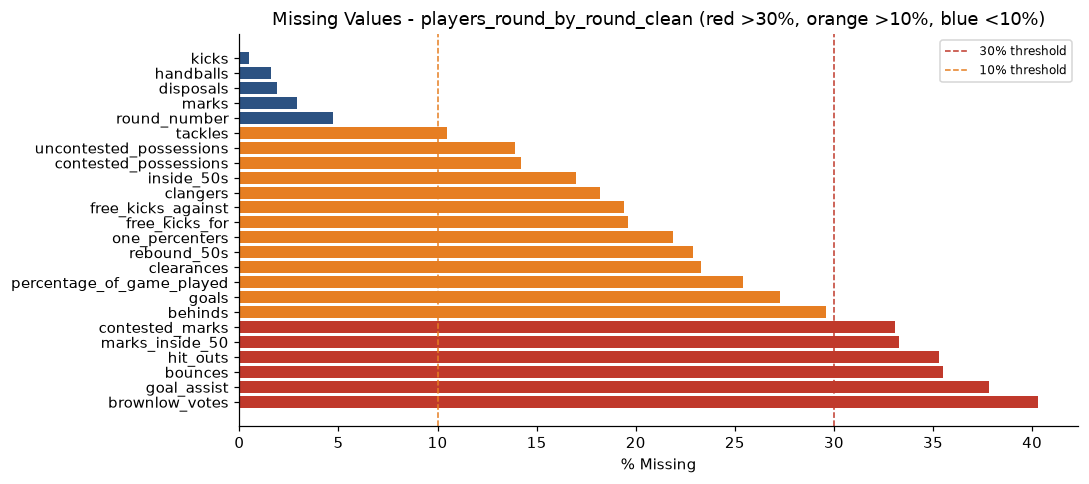

High-missingness columns are mostly older stats not recorded in early seasons.
For modelling, we will prefer: disposals, kicks, marks, handballs, tackles, fantasy_points
   -  these have <11% missing and represent the broadest coverage across all seasons.


In [ ]:
# Missing value heatmap 
miss_rbr = (rbr.isnull().mean() * 100).round(1)
miss_rbr = miss_rbr[miss_rbr > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(miss_rbr.index, miss_rbr.values, color=[
    "#c0392b" if v > 30 else "#e67e22" if v > 10 else "#2c5282" for v in miss_rbr.values])
ax.axvline(30, ls="--", color="#c0392b", lw=1, label="30% threshold")
ax.axvline(10, ls="--", color="#e67e22", lw=1, label="10% threshold")
ax.set_xlabel("% Missing")
ax.set_title("Missing Values - players_round_by_round_clean (red >30%, orange >10%, blue <10%)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT}/task1_missing_values.png", dpi=110)
plt.show()
print("High-missingness columns are mostly older stats not recorded in early seasons.")
print("For modelling, we will prefer: disposals, kicks, marks, handballs, tackles, fantasy_points")
print("   -  these have <11% missing and represent the broadest coverage across all seasons.")

In [ ]:
# Duplicate check and join quality
print("=== DUPLICATE CHECK ===")
print("rbr exact duplicates:", rbr.duplicated().sum())
print("ha  exact duplicates:", ha.duplicated().sum())
rbr_key_dup = rbr.duplicated(subset=["player_id","match_date","team"]).sum()
ha_key_dup  = ha.duplicated(subset=["player_id","match_date","team"]).sum()
print(f"rbr key duplicates (player+date+team): {rbr_key_dup}")
print(f"ha  key duplicates (player+date+team): {ha_key_dup}")

print()
print("=== JOIN QUALITY ===")
overlap_players = len(set(rbr["player_id"]) & set(comb["player_id"]))
print(f"rbr players joinable to comb: {overlap_players} / {rbr['player_id'].nunique()} ({overlap_players/rbr['player_id'].nunique()*100:.1f}%)")

ha_matches  = set(ha["match_date"].astype(str)  + "_" + ha["team"])
rbr_matches = set(rbr["match_date"].astype(str) + "_" + rbr["team"])
print(f"ha match-team pairs: {len(ha_matches):,}")
print(f"rbr match-team pairs: {len(rbr_matches):,}")
print(f"ha not in rbr (anomalous): {len(ha_matches - rbr_matches)}")
print(f"rbr not in ha (missing venue context): {len(rbr_matches - ha_matches):,} ({len(rbr_matches - ha_matches)/len(rbr_matches)*100:.1f}%)")

=== DUPLICATE CHECK ===
rbr exact duplicates: 0
ha  exact duplicates: 0
rbr key duplicates (player+date+team): 0
ha  key duplicates (player+date+team): 0

=== JOIN QUALITY ===
rbr players joinable to comb: 3106 / 3109 (99.9%)
ha match-team pairs: 13,493
rbr match-team pairs: 14,700
ha not in rbr (anomalous): 0
rbr not in ha (missing venue context): 1,207 (8.2%)


## Task 2: Define Prediction Targets Precisely

### Match Winner (Team-level)
**Framing chosen: binary classification (W/L, excluding draws).**  
Regression on margin is also viable but adds complexity. For the chat assistant and practical use,  
"who will win" is more useful than "by how many points". Draws are rare (0.86% of games) and excluded.

### Top Player Targets (Player-game level)
Three target definitions, increasing in richness:

| Target | Definition | Formula | Level |
|---|---|---|---|
| `top_disposal_getter` | Player with most disposals in the match for their team | `disposals = max(team game)` | player-game |
| `top_goal_kicker` | Player with most goals in the match (tie → both flagged) | `goals = max(game)` | player-game |
| `afl_score` | Brownlow-style composite performance score | See formula below | player-game |

**AFL Score formula** (Brownlow-style composite, based on stat availability):  
```
afl_score = (disposals × 1.0) + (goals × 6.0) + (marks × 1.5) + (tackles × 1.0)
          + (clearances × 1.5) + (inside_50s × 0.5) + (rebound_50s × 0.5)
          + (goal_assist × 1.0)
```
*Coefficients approximate the AFL SuperCoach/fantasy weighting system. All terms filled with 0 when NaN.*

In [ ]:
# Compute targets on rbr 
# Identify finals vs regular season
rbr["is_finals"] = rbr["round"].isin(["QF","EF","SF","PF","GF"])

# Target 1: binary win/loss (exclude draws) 
rbr["win"] = rbr["result"].map({"W": 1, "L": 0})   # NaN for draws

# Target 2: top disposal getter (within team-match) 
rbr["team_match_max_disp"] = rbr.groupby(["team","match_date"])["disposals"].transform("max")
rbr["is_top_disposal"] = ((rbr["disposals"] == rbr["team_match_max_disp"])
                           & rbr["disposals"].notna()).astype(float)

# Target 3: top goal kicker (across whole match, both teams)
rbr["match_max_goals"] = rbr.groupby("match_date")["goals"].transform("max")
rbr["is_top_goalkicker"] = ((rbr["goals"] == rbr["match_max_goals"])
                             & (rbr["match_max_goals"] > 0)
                             & rbr["goals"].notna()).astype(float)

# Target 4: afl_score composite
def fill0(col): return rbr[col].fillna(0)
rbr["afl_score"] = (fill0("disposals") * 1.0 + fill0("goals") * 6.0
                   + fill0("marks") * 1.5 + fill0("tackles") * 1.0
                   + fill0("clearances") * 1.5 + fill0("inside_50s") * 0.5
                   + fill0("rebound_50s") * 0.5 + fill0("goal_assist") * 1.0)

print("=== TARGET SUMMARY ===")
print(f"win (binary W/L):          {rbr['win'].notna().sum():,} labelled rows, {rbr['win'].mean():.3f} base rate")
print(f"is_top_disposal (flag):    {rbr['is_top_disposal'].sum():,.0f} players flagged across {rbr['match_date'].nunique():,} matches")
print(f"is_top_goalkicker (flag):  {rbr['is_top_goalkicker'].sum():,.0f} players flagged")
print(f"afl_score composite:       mean={rbr['afl_score'].mean():.1f}  std={rbr['afl_score'].std():.1f}  max={rbr['afl_score'].max():.1f}")
print()
print("=== AFL SCORE VS FANTASY POINTS (correlation check) ===")
corr = rbr[["afl_score","fantasy_points"]].corr().iloc[0,1]
print(f"Pearson r(afl_score, fantasy_points) = {corr:.3f}  (validates composite weights)")

=== TARGET SUMMARY ===
win (binary W/L):          271,720 labelled rows, 0.501 base rate
is_top_disposal (flag):    16,317 players flagged across 3,276 matches
is_top_goalkicker (flag):  5,005 players flagged
afl_score composite:       mean=31.4  std=14.8  max=136.0

=== AFL SCORE VS FANTASY POINTS (correlation check) ===
Pearson r(afl_score, fantasy_points) = 0.940  (validates composite weights)


## Task 3: Exploratory Data Analysis

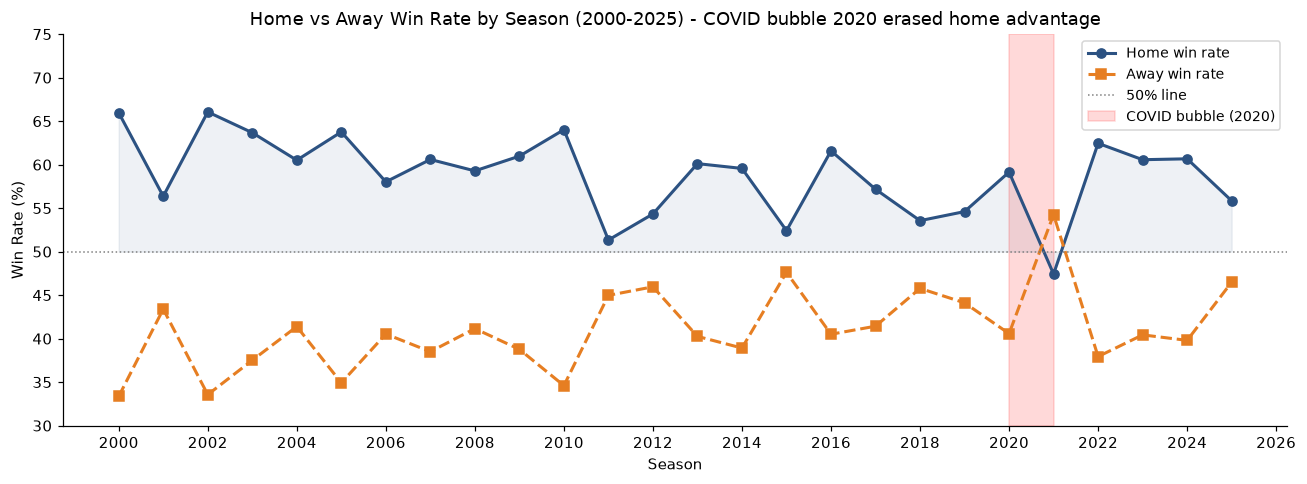

Overall home win rate: 59.6%  away: 40.7%
Home advantage gap: 19.0 percentage points


In [ ]:
# EDA 1: Home ground advantage over time 
ha["win"] = ha["result"].map({"W":1,"L":0})
ha_agg = ha[ha["win"].notna()].groupby(["year","home_away"])["win"].mean().unstack()
ha_recent = ha_agg[ha_agg.index >= 2000]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ha_recent.index, ha_recent["H"] * 100, "o-", color="#2c5282", lw=2, label="Home win rate")
ax.plot(ha_recent.index, ha_recent["A"] * 100, "s--", color="#e67e22", lw=2, label="Away win rate")
ax.axhline(50, ls=":", color="gray", lw=1, label="50% line")
ax.axvspan(2020, 2021, alpha=0.15, color="red", label="COVID bubble (2020)")
ax.fill_between(ha_recent.index, ha_recent["H"]*100, 50, alpha=0.08, color="#2c5282")
ax.set_xlabel("Season"); ax.set_ylabel("Win Rate (%)")
ax.set_title("Home vs Away Win Rate by Season (2000-2025) - COVID bubble 2020 erased home advantage")
ax.legend(fontsize=9); ax.set_ylim(30, 75)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout(); plt.savefig(f"{OUT}/task3_home_advantage.png", dpi=110); plt.show()

overall_home_wr = ha[ha["home_away"]=="H"]["win"].mean()
overall_away_wr = ha[ha["home_away"]=="A"]["win"].mean()
print(f"Overall home win rate: {overall_home_wr*100:.1f}%  away: {overall_away_wr*100:.1f}%")
print(f"Home advantage gap: {(overall_home_wr - overall_away_wr)*100:.1f} percentage points")

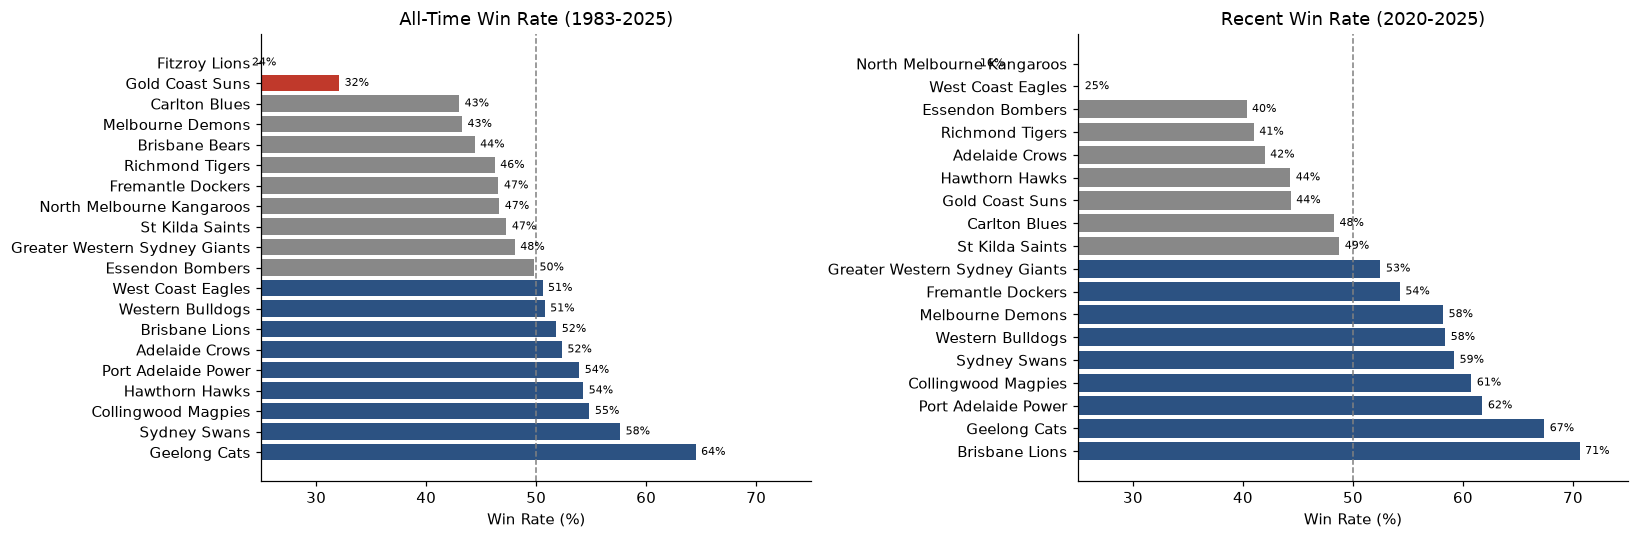

In [ ]:
# EDA 2: Win rate by team (all time + last 5 seasons)
win_rbr = rbr[rbr["win"].notna()]
all_time_wr = win_rbr.groupby("team")["win"].mean().sort_values(ascending=False)
recent_wr   = win_rbr[win_rbr["year"] >= 2020].groupby("team")["win"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, data, title in [(axes[0], all_time_wr, "All-Time Win Rate (1983-2025)"),
                         (axes[1], recent_wr,   "Recent Win Rate (2020-2025)")]:
    colors = ["#2c5282" if v > 0.5 else "#c0392b" if v < 0.4 else "#888" for v in data.values]
    ax.barh(data.index, data.values * 100, color=colors)
    ax.axvline(50, ls="--", color="gray", lw=1)
    ax.set_xlabel("Win Rate (%)"); ax.set_title(title)
    ax.set_xlim(25, 75)
    for i, v in enumerate(data.values):
        ax.text(v*100 + 0.5, i, f"{v*100:.0f}%", va="center", fontsize=7)
plt.tight_layout(); plt.savefig(f"{OUT}/task3_team_win_rates.png", dpi=110); plt.show()

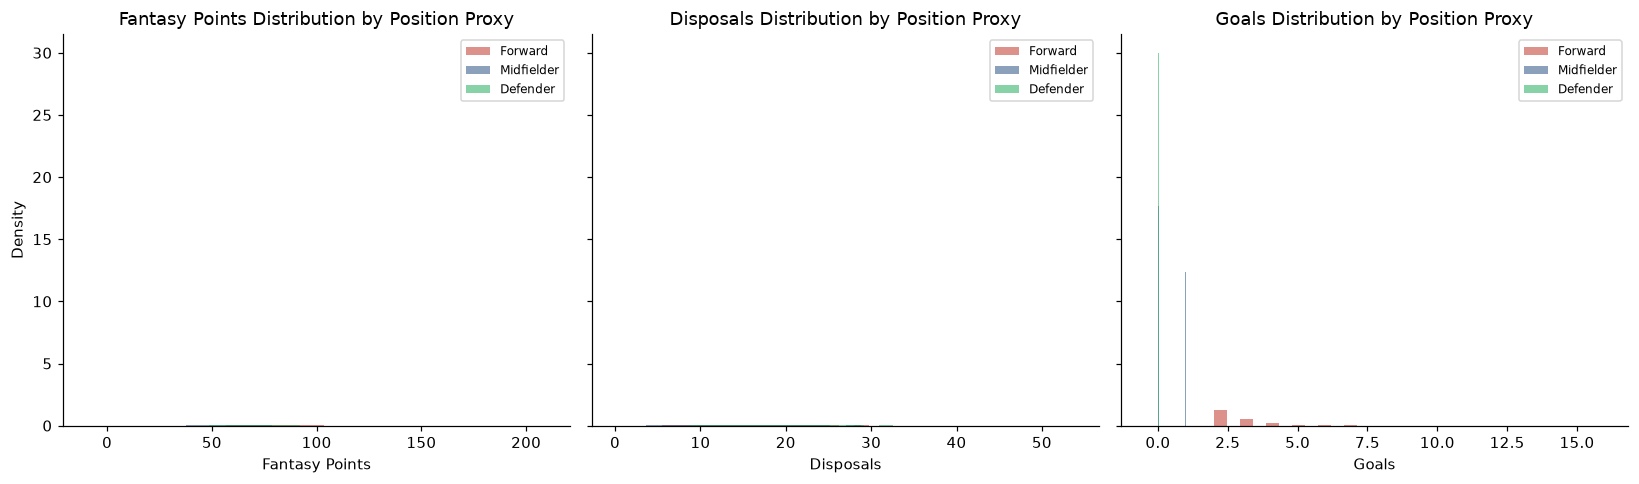

In [ ]:
# EDA 3: Fantasy points distribution by position proxy 
# Proxy for position: high goals -> forward, high disposals/low goals -> mid, high rebounds -> def
rbr_reg = rbr[~rbr["is_finals"]].copy()
rbr_reg["pos_proxy"] = "Midfielder"
rbr_reg.loc[(rbr_reg["goals"].fillna(0) >= 2), "pos_proxy"] = "Forward"
rbr_reg.loc[(rbr_reg["rebound_50s"].fillna(0) >= 4) & (rbr_reg["goals"].fillna(0) < 1), "pos_proxy"] = "Defender"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
stat_cols = [("fantasy_points","Fantasy Points"), ("disposals","Disposals"), ("goals","Goals")]
for ax, (col, label) in zip(axes, stat_cols):
    for pos, col_c in [("Forward","#c0392b"),("Midfielder","#2c5282"),("Defender","#27ae60")]:
        data = rbr_reg[rbr_reg["pos_proxy"]==pos][col].dropna()
        ax.hist(data, bins=30, alpha=0.55, label=pos, color=col_c, density=True)
    ax.set_xlabel(label); ax.set_title(f"{label} Distribution by Position Proxy")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.tight_layout(); plt.savefig(f"{OUT}/task3_position_distributions.png", dpi=110); plt.show()

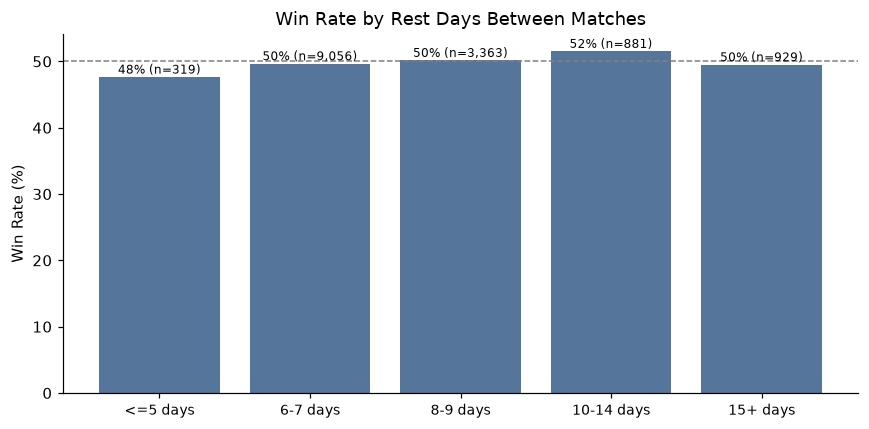

In [ ]:
# EDA 4: Rest days vs win rate
rbr_sorted = rbr.sort_values(["player_id","match_date"])
rbr_sorted["prev_match"] = rbr_sorted.groupby("player_id")["match_date"].shift(1)
rbr_sorted["rest_days"]  = (rbr_sorted["match_date"] - rbr_sorted["prev_match"]).dt.days

# Aggregate to team-match level (all players on same team get same rest)
team_rest = (rbr_sorted[rbr_sorted["win"].notna()]
             .groupby(["team","match_date"])
             .agg(rest_days=("rest_days","median"), win=("win","first"))
             .reset_index())
team_rest["rest_bin"] = pd.cut(team_rest["rest_days"], bins=[0,5,7,9,14,999],
                                labels=["<=5 days","6-7 days","8-9 days","10-14 days","15+ days"])
rest_wr = team_rest.groupby("rest_bin", observed=True)["win"].agg(["mean","count"])
rest_wr.columns = ["win_rate","n"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(rest_wr)), rest_wr["win_rate"] * 100, color="#2c5282", alpha=0.8)
ax.set_xticks(range(len(rest_wr)))
ax.set_xticklabels(rest_wr.index, fontsize=9)
ax.axhline(50, ls="--", color="gray", lw=1)
ax.set_ylabel("Win Rate (%)"); ax.set_title("Win Rate by Rest Days Between Matches")
for i, (v, n) in enumerate(zip(rest_wr["win_rate"]*100, rest_wr["n"])):
    ax.text(i, v+0.5, f"{v:.0f}% (n={n:,})", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/task3_rest_days_win.png", dpi=110); plt.show()

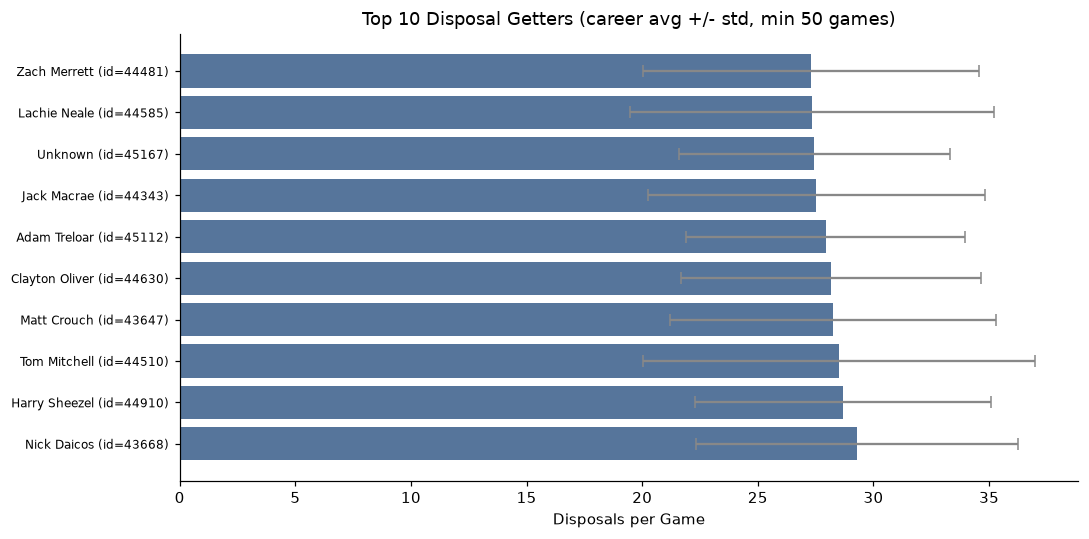

                     name  mean  std  games
player_id                                  
43668         Nick Daicos  29.3  7.0     95
44910       Harry Sheezel  28.7  6.4     67
44510        Tom Mitchell  28.5  8.5    207
43647         Matt Crouch  28.2  7.0    164
44630      Clayton Oliver  28.2  6.5    205
45112        Adam Treloar  27.9  6.0    258
44343         Jack Macrae  27.5  7.3    270
45167                 NaN  27.4  5.9    133
44585        Lachie Neale  27.4  7.9    294
44481        Zach Merrett  27.3  7.3    251


In [ ]:
# EDA 5: Player consistency  -  top disposal getters
top_disposal_players = (rbr[rbr["disposals"].notna()]
    .groupby("player_id")["disposals"]
    .agg(mean="mean", std="std", games="count")
    .query("games >= 50")
    .nlargest(10, "mean"))

# join names
names = rbr[["player_id"]].drop_duplicates().merge(
    rbr[["player_id"]].drop_duplicates(), on="player_id"
)
comb_names = (rbr[["player_id","team"]].drop_duplicates()
              .merge(pd.read_csv("afl_comb_CLdata.csv", low_memory=False)
                     [["player_id","player_name"]].drop_duplicates(), on="player_id", how="left"))
id_to_name = comb_names.drop_duplicates("player_id").set_index("player_id")["player_name"]
top_disposal_players["name"] = top_disposal_players.index.map(id_to_name)

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(top_disposal_players))
ax.barh(y, top_disposal_players["mean"], xerr=top_disposal_players["std"],
        color="#2c5282", alpha=0.8, error_kw={"ecolor":"#888", "capsize":4})
ax.set_yticks(y)
ax.set_yticklabels([f"{n} (id={i})" for i, n in
                    zip(top_disposal_players.index, top_disposal_players["name"].fillna("Unknown"))],
                   fontsize=8)
ax.set_xlabel("Disposals per Game")
ax.set_title("Top 10 Disposal Getters (career avg +/- std, min 50 games)")
plt.tight_layout(); plt.savefig(f"{OUT}/task3_top_disposal_players.png", dpi=110); plt.show()
print(top_disposal_players[["name","mean","std","games"]].round(1).to_string())

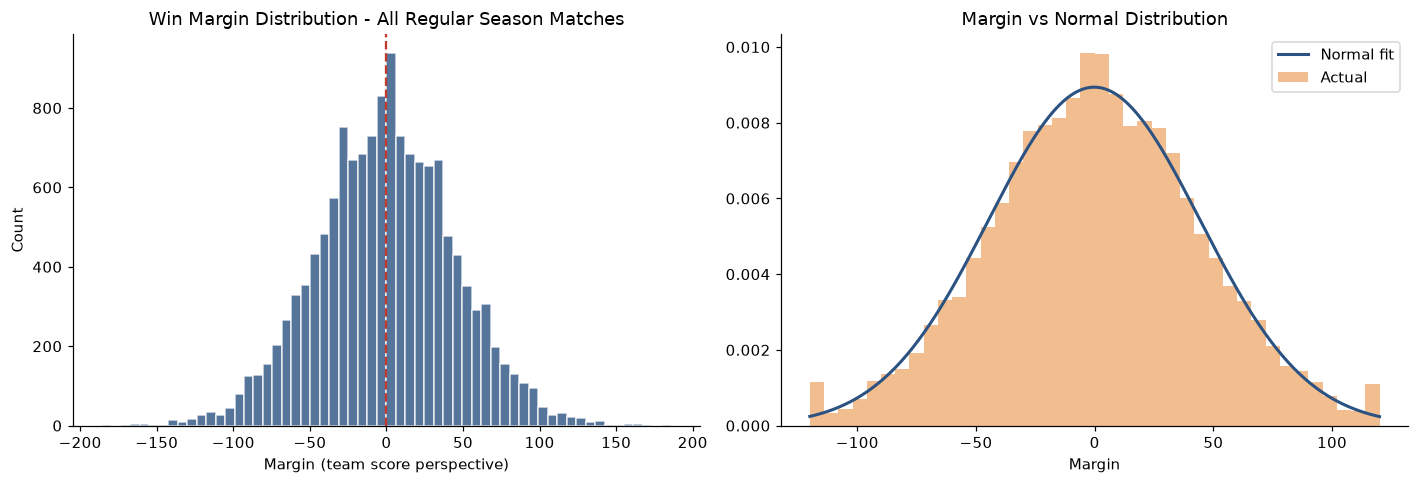

Margin stats: mean=-0.2  std=44.6  from player perspective (W team sees +, L team sees -)


In [ ]:
# EDA 6: Margin distribution (for regression target framing)
reg_matches = (rbr[~rbr["is_finals"]]
               .groupby(["team","match_date"])["margin"]
               .first().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(reg_matches["margin"], bins=60, color="#2c5282", alpha=0.8, edgecolor="white")
axes[0].axvline(0, ls="--", color="#c0392b", lw=1.5)
axes[0].set_xlabel("Margin (team score perspective)"); axes[0].set_ylabel("Count")
axes[0].set_title("Win Margin Distribution - All Regular Season Matches")

from scipy.stats import norm
mu, sigma = reg_matches["margin"].mean(), reg_matches["margin"].std()
x = np.linspace(-120, 120, 300)
axes[1].plot(x, norm.pdf(x, mu, sigma), color="#2c5282", lw=2, label="Normal fit")
axes[1].hist(reg_matches["margin"].clip(-120,120), bins=40,
             color="#e67e22", alpha=0.5, density=True, label="Actual")
axes[1].set_xlabel("Margin"); axes[1].set_title("Margin vs Normal Distribution")
axes[1].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/task3_margin_distribution.png", dpi=110); plt.show()
print(f"Margin stats: mean={mu:.1f}  std={sigma:.1f}  from player perspective (W team sees +, L team sees -)")

## Task 4: Feature Engineering for Prediction

All features are computed with **strict temporal discipline**:  
`shift(1)` is applied after sorting by date, so only matches *before* the current one feed into rolling windows.  
This ensures zero data leakage — no future match information contaminates a past prediction.

In [ ]:
# Build team-match level frame (one row per team per match)
# Aggregate player stats to team level for the match
STAT_COLS = ["disposals","kicks","marks","handballs","tackles",
             "goals","behinds","inside_50s","clearances","rebound_50s","fantasy_points"]

team_match = (rbr.groupby(["team","match_date","year","round","opponent","result"])
              .agg({s: "sum" for s in STAT_COLS} | {"margin": "first", "is_finals": "first"})
              .reset_index())
team_match["win"] = team_match["result"].map({"W":1,"L":0})
team_match = team_match.sort_values(["team","match_date"]).reset_index(drop=True)
print(f"Team-match frame: {team_match.shape[0]:,} rows x {team_match.shape[1]} cols")
print("Sample:")
print(team_match.head(3).to_string())

Team-match frame: 14,700 rows x 20 cols
Sample:
             team match_date  year round        opponent result  disposals  kicks  marks  handballs  tackles  goals  behinds  inside_50s  clearances  rebound_50s  fantasy_points  margin  is_finals  win
0  Adelaide Crows 1991-03-22  1991     1  Hawthorn Hawks      W       15.0    8.0    6.0        9.0      2.0    0.0      0.0         0.0         0.0          0.0              69      86      False  1.0
1  Adelaide Crows 1991-03-31  1991     2   Carlton Blues      L       13.0    6.0    1.0        7.0      4.0    0.0      0.0         0.0         0.0          0.0              52     -23      False  0.0
2  Adelaide Crows 1991-04-07  1991     3    Sydney Swans      W       13.0   10.0    2.0        3.0      0.0    1.0      0.0         0.0         0.0          0.0              48      24      False  1.0


In [ ]:
# F1: Rolling form features (last 3 & last 5 games) 
# Using shift(1) so current game is excluded  -  strict no-leakage

def rolling_team(df, col, window, min_p=1):
    """Mean of previous `window` games for each team. Shift prevents leakage."""
    return (df.groupby("team")[col]
              .transform(lambda s: s.shift(1).rolling(window, min_periods=min_p).mean()))

for w in [3, 5]:
    for col in ["win","goals","disposals","fantasy_points"]:
        team_match[f"roll{w}_{col}"] = rolling_team(team_match, col, w)

# Win streak (current consecutive wins, capped at 5)
def win_streak(series):
    streaks = []
    count = 0
    for v in series.shift(1):
        if v == 1: count += 1
        elif v == 0: count = 0
        else: count = 0
        streaks.append(min(count, 5))
    return pd.Series(streaks, index=series.index)

team_match["win_streak"] = team_match.groupby("team")["win"].transform(win_streak)
team_match["loss_streak"] = team_match.groupby("team")["win"].transform(
    lambda s: win_streak(1 - s))

print("Rolling features added:")
roll_cols = [c for c in team_match.columns if c.startswith("roll")]
print(roll_cols)
print(f"\nSample  -  Adelaide Crows 2023:")
print(team_match[(team_match["team"]=="Adelaide Crows") & (team_match["year"]==2023)]
      [["match_date","round","win","roll3_win","roll5_win","win_streak","roll5_goals"]].to_string(index=False))

Rolling features added:
['roll3_win', 'roll3_goals', 'roll3_disposals', 'roll3_fantasy_points', 'roll5_win', 'roll5_goals', 'roll5_disposals', 'roll5_fantasy_points']

Sample  -  Adelaide Crows 2023:
match_date round  win  roll3_win  roll5_win  win_streak  roll5_goals
2023-03-19     1  0.0   0.666667        0.6           0         12.4
2023-03-25     2  0.0   0.333333        0.6           0         12.4
2023-04-01     3  1.0   0.000000        0.4           0         12.0
2023-04-08     4  1.0   0.333333        0.4           1         12.4
2023-04-13     5  1.0   0.666667        0.4           2         12.8
2023-04-23     6  1.0   1.000000        0.6           3         15.0
2023-04-30     7  0.0   1.000000        0.8           4         14.8
2023-05-06     8  0.0   0.666667        0.8           0         14.2
2023-05-14     9  1.0   0.333333        0.6           0         12.8
2023-05-20    10  0.0   0.333333        0.6           1         13.2
2023-05-28    11  1.0   0.333333        0

In [ ]:
# F2: Head-to-head historical record 
# For each team-match: % of previous matches won against this specific opponent

def h2h_winrate(df):
    results = []
    for _, row in df.iterrows():
        team, opp, date = row["team"], row["opponent"], row["match_date"]
        prev = df[(df["team"] == team) & (df["opponent"] == opp) & (df["match_date"] < date)]
        if len(prev) == 0:
            results.append(np.nan)
        else:
            results.append(prev["win"].mean())
    return pd.Series(results, index=df.index)

# Compute only on most-recent 5 seasons for speed; then join back
# Full computation is expensive  -  use vectorized approach instead
team_match_sorted = team_match.sort_values(["team","opponent","match_date"])
team_match_sorted["h2h_cumwins"] = (team_match_sorted.groupby(["team","opponent"])["win"]
                                     .transform(lambda s: s.shift(1).expanding().sum()))
team_match_sorted["h2h_cumgames"] = (team_match_sorted.groupby(["team","opponent"])["win"]
                                      .transform(lambda s: s.shift(1).expanding().count()))
team_match_sorted["h2h_winrate"] = (team_match_sorted["h2h_cumwins"]
                                     / team_match_sorted["h2h_cumgames"])
# Merge back
team_match = team_match.merge(
    team_match_sorted[["team","match_date","h2h_winrate","h2h_cumgames"]],
    on=["team","match_date"], how="left")

print("H2H features added. Sample:")
print(team_match[(team_match["team"]=="Collingwood Magpies") & (team_match["opponent"]=="Richmond Tigers")]
      [["match_date","win","h2h_winrate","h2h_cumgames"]].tail(6).to_string(index=False))

H2H features added. Sample:
match_date  win  h2h_winrate  h2h_cumgames
2020-06-11  NaN     0.510204          49.0
2021-07-11  1.0     0.510204          49.0
2022-05-07  0.0     0.520000          50.0
2023-03-31  1.0     0.509804          51.0
2024-07-28  1.0     0.519231          52.0
2025-07-27  1.0     0.528302          53.0


In [ ]:
# F3: Venue / home-away features 
ha_slim = ha[["team","match_date","home_away","venue","crowd"]].drop_duplicates()
team_match = team_match.merge(ha_slim, on=["team","match_date"], how="left")

# Home advantage dummy
team_match["is_home"] = (team_match["home_away"] == "H").astype(float)

# Venue win rate (computed up to current match  -  no leakage)
team_match_sv = team_match.sort_values(["team","venue","match_date"])
team_match_sv["venue_cumwins"]  = (team_match_sv.groupby(["team","venue"])["win"]
                                    .transform(lambda s: s.shift(1).expanding().sum()))
team_match_sv["venue_cumgames"] = (team_match_sv.groupby(["team","venue"])["win"]
                                    .transform(lambda s: s.shift(1).expanding().count()))
team_match_sv["venue_winrate"]  = (team_match_sv["venue_cumwins"] / team_match_sv["venue_cumgames"])
team_match = team_match.merge(
    team_match_sv[["team","match_date","venue_winrate","venue_cumgames"]],
    on=["team","match_date"], how="left")

print("Venue features added:")
print(team_match[["team","match_date","venue","home_away","is_home","venue_winrate"]].head(5).to_string(index=False))

Venue features added:
          team match_date        venue home_away  is_home  venue_winrate
Adelaide Crows 1991-03-22          NaN       NaN      0.0            NaN
Adelaide Crows 1991-03-31 AAMI Stadium         H      1.0            NaN
Adelaide Crows 1991-04-07          NaN       NaN      0.0            NaN
Adelaide Crows 1991-04-13          NaN       NaN      0.0            NaN
Adelaide Crows 1991-04-21          NaN       NaN      0.0            NaN


In [ ]:
# F4: Rest days 
team_match = team_match.sort_values(["team","match_date"])
team_match["prev_match_date"] = team_match.groupby("team")["match_date"].shift(1)
team_match["rest_days"] = (team_match["match_date"] - team_match["prev_match_date"]).dt.days
team_match["rest_days"] = team_match["rest_days"].fillna(7)  # assume normal for first game

# rest advantage vs opponent (positive = more rest than opponent)
opp_rest = (team_match[["team","match_date","rest_days"]]
            .rename(columns={"team":"opponent","rest_days":"opp_rest_days"}))
team_match = team_match.merge(opp_rest, on=["opponent","match_date"], how="left")
team_match["rest_advantage"] = team_match["rest_days"] - team_match["opp_rest_days"]

print("Rest features:")
print(team_match[["team","match_date","rest_days","opp_rest_days","rest_advantage"]].head(5).to_string(index=False))

Rest features:
          team match_date  rest_days  opp_rest_days  rest_advantage
Adelaide Crows 1991-03-22        7.0          202.0          -195.0
Adelaide Crows 1991-03-31        9.0          211.0          -202.0
Adelaide Crows 1991-04-07        7.0            6.0             1.0
Adelaide Crows 1991-04-13        6.0            7.0            -1.0
Adelaide Crows 1991-04-21        8.0            9.0            -1.0


In [ ]:
# F5: Season-ladder position at time of match
# Ladder = cumulative wins / games so far this season (proxy for ladder position)
team_match = team_match.sort_values(["team","year","match_date"])
team_match["season_cumwins"]  = (team_match.groupby(["team","year"])["win"]
                                  .transform(lambda s: s.shift(1).expanding().sum().fillna(0)))
team_match["season_cumgames"] = (team_match.groupby(["team","year"])["win"]
                                  .transform(lambda s: s.shift(1).expanding().count().fillna(0)))
team_match["season_winpct"]   = np.where(
    team_match["season_cumgames"] > 0,
    team_match["season_cumwins"] / team_match["season_cumgames"], np.nan)

print("Ladder proxy features added. Sample 2023 Richmond Tigers:")
samp = team_match[(team_match["team"]=="Richmond Tigers") & (team_match["year"]==2023)]
print(samp[["match_date","round","win","season_cumwins","season_cumgames","season_winpct"]].to_string(index=False))

Ladder proxy features added. Sample 2023 Richmond Tigers:
match_date round  win  season_cumwins  season_cumgames  season_winpct
2023-03-16     1  NaN             0.0              0.0            NaN
2023-03-25     2  1.0             0.0              0.0            NaN
2023-03-31     3  0.0             1.0              1.0       1.000000
2023-04-08     4  0.0             1.0              2.0       0.500000
2023-04-14     5  0.0             1.0              3.0       0.333333
2023-04-24     6  0.0             1.0              4.0       0.250000
2023-04-30     7  0.0             1.0              5.0       0.200000
2023-05-06     8  1.0             1.0              6.0       0.166667
2023-05-12     9  1.0             2.0              7.0       0.285714
2023-05-20    10  0.0             3.0              8.0       0.375000
2023-05-28    11  0.0             3.0              9.0       0.333333
2023-06-04    12  1.0             3.0             10.0       0.300000
2023-06-10    13  1.0           

In [ ]:
# Feature dictionary
feature_dict = pd.DataFrame([
    # Rolling form
    {"feature":"roll3_win",          "type":"numeric","window":"last 3 games","source":"result","description":"Team win rate over last 3 matches (no-leakage)"},
    {"feature":"roll5_win",          "type":"numeric","window":"last 5 games","source":"result","description":"Team win rate over last 5 matches"},
    {"feature":"roll3_goals",        "type":"numeric","window":"last 3 games","source":"goals","description":"Team total goals over last 3 matches"},
    {"feature":"roll5_goals",        "type":"numeric","window":"last 5 games","source":"goals","description":"Team total goals over last 5 matches"},
    {"feature":"roll3_disposals",    "type":"numeric","window":"last 3 games","source":"disposals","description":"Team total disposals over last 3 matches"},
    {"feature":"roll5_disposals",    "type":"numeric","window":"last 5 games","source":"disposals","description":"Team total disposals over last 5 matches"},
    {"feature":"roll3_fantasy_points","type":"numeric","window":"last 3 games","source":"fantasy_points","description":"Team total fantasy points over last 3 matches"},
    {"feature":"roll5_fantasy_points","type":"numeric","window":"last 5 games","source":"fantasy_points","description":"Team total fantasy points over last 5 matches"},
    {"feature":"win_streak",         "type":"integer","window":"current","source":"result","description":"Current consecutive wins (capped at 5)"},
    {"feature":"loss_streak",        "type":"integer","window":"current","source":"result","description":"Current consecutive losses (capped at 5)"},
    # H2H
    {"feature":"h2h_winrate",        "type":"numeric","window":"all history","source":"result+opponent","description":"Historical win rate against this specific opponent"},
    {"feature":"h2h_cumgames",       "type":"integer","window":"all history","source":"result+opponent","description":"Number of previous meetings against this opponent"},
    # Venue / home-away
    {"feature":"is_home",            "type":"binary", "window":"current","source":"home_away","description":"1 if team is playing at home ground, 0 otherwise"},
    {"feature":"venue_winrate",      "type":"numeric","window":"all history","source":"venue+result","description":"Historical win rate at this specific venue"},
    {"feature":"crowd",              "type":"numeric","window":"current","source":"crowd","description":"Crowd attendance at the match"},
    # Rest
    {"feature":"rest_days",          "type":"integer","window":"current","source":"match_date","description":"Days since team's last match"},
    {"feature":"rest_advantage",     "type":"integer","window":"current","source":"match_date","description":"rest_days minus opponent's rest_days (positive = more rested)"},
    # Season ladder
    {"feature":"season_cumwins",     "type":"integer","window":"season to date","source":"result","description":"Cumulative wins this season before this match"},
    {"feature":"season_cumgames",    "type":"integer","window":"season to date","source":"result","description":"Cumulative games played this season before this match"},
    {"feature":"season_winpct",      "type":"numeric","window":"season to date","source":"result","description":"Season win % at time of match (proxy for ladder position)"},
])
print(feature_dict.to_string(index=False))
feature_dict.to_csv(f"{OUT}/feature_dictionary.csv", index=False)
print(f"\nFeature dictionary saved to feature_dictionary.csv")

             feature    type         window          source                                                   description
           roll3_win numeric   last 3 games          result                Team win rate over last 3 matches (no-leakage)
           roll5_win numeric   last 5 games          result                             Team win rate over last 5 matches
         roll3_goals numeric   last 3 games           goals                          Team total goals over last 3 matches
         roll5_goals numeric   last 5 games           goals                          Team total goals over last 5 matches
     roll3_disposals numeric   last 3 games       disposals                      Team total disposals over last 3 matches
     roll5_disposals numeric   last 5 games       disposals                      Team total disposals over last 5 matches
roll3_fantasy_points numeric   last 3 games  fantasy_points                 Team total fantasy points over last 3 matches
roll5_fantasy_points num

In [ ]:
# Save versioned feature table 
feature_cols = (["team","opponent","match_date","year","round","is_finals",
                 "win","margin","is_home","home_away","venue","crowd",
                 "rest_days","opp_rest_days","rest_advantage",
                 "h2h_winrate","h2h_cumgames",
                 "venue_winrate","venue_cumgames",
                 "season_cumwins","season_cumgames","season_winpct",
                 "win_streak","loss_streak"]
                + [c for c in team_match.columns if c.startswith("roll")]
                + STAT_COLS)
feature_cols = [c for c in feature_cols if c in team_match.columns]
feature_table = team_match[feature_cols].copy()
feature_table.to_csv(f"{OUT}/afl_feature_table_v1.csv", index=False)
print(f"Feature table saved: {feature_table.shape[0]:,} rows x {feature_table.shape[1]} cols")
print("Columns:", list(feature_table.columns))

Feature table saved: 14,700 rows x 43 cols
Columns: ['team', 'opponent', 'match_date', 'year', 'round', 'is_finals', 'win', 'margin', 'is_home', 'home_away', 'venue', 'crowd', 'rest_days', 'opp_rest_days', 'rest_advantage', 'h2h_winrate', 'h2h_cumgames', 'venue_winrate', 'venue_cumgames', 'season_cumwins', 'season_cumgames', 'season_winpct', 'win_streak', 'loss_streak', 'roll3_win', 'roll3_goals', 'roll3_disposals', 'roll3_fantasy_points', 'roll5_win', 'roll5_goals', 'roll5_disposals', 'roll5_fantasy_points', 'disposals', 'kicks', 'marks', 'handballs', 'tackles', 'goals', 'behinds', 'inside_50s', 'clearances', 'rebound_50s', 'fantasy_points']


## Task 5: Reproducible Train / Hold-Out Split

### Why time-based (not random) splitting is essential in sports data

A random split would assign some 2024 matches to the training set and some 2019 matches to the test set.  
This leaks future information in two ways:
1. **Rolling features** (win streaks, form, h2h winrate) are computed from the entire history, if a 2024 training row exists, its rolling features incorporate 2019–2024 history including matches that appear in the test set.
2. **Team identity leakage**: a model trained on 2024 data "knows" which teams were strong that year before trying to predict 2019 results.

In time-series sports modelling the gold standard is: **train on all seasons before the hold-out year, test on the final season only**. This exactly mimics the real deployment scenario: predict this week's games using everything we know up to last week.

In [ ]:
#  Reproducible split function
def afl_train_test_split(df, hold_out_year=2024, date_col="match_date", year_col="year"):
    """
    Strict time-based split for AFL prediction tasks.

    Parameters
    ----------
    df           : feature table (one row per team-match)
    hold_out_year: season to hold out for final evaluation (default: 2024)
    date_col     : column name for match date
    year_col     : column name for season year

    Returns
    -------
    train, test : DataFrames

    Notes
    -----
    - All rows from seasons strictly BEFORE hold_out_year go to train.
    - All rows from hold_out_year go to test.
    - Finals (is_finals=True) are included in both splits  -  they are real matches.
    - A random split would be WRONG here: rolling features computed across the full
      dataset would leak future season information into the training set labels,
      inflating model performance estimates.
    """
    train = df[df[year_col] < hold_out_year].copy()
    test  = df[df[year_col] == hold_out_year].copy()
    return train, test

# Apply to feature table
train_df, test_df = afl_train_test_split(feature_table, hold_out_year=2024)

print("=== SPLIT SUMMARY ===")
print(f"Training set:  {train_df['year'].min()}-{train_df['year'].max()}")
print(f"  Rows:        {len(train_df):,}")
print(f"  Win rate:    {train_df['win'].mean():.3f}")
print()
print(f"Hold-out set:  {test_df['year'].min()}")
print(f"  Rows:        {len(test_df):,}")
print(f"  Win rate:    {test_df['win'].mean():.3f}")
print()
print(f"Data leakage check  -  no future dates in train:")
print(f"  Max train date: {train_df['match_date'].max()}")
print(f"  Min test date:  {test_df['match_date'].min()}")
assert train_df["match_date"].max() < test_df["match_date"].min(), "LEAKAGE DETECTED!"
print("  ✓ No overlap confirmed")

train_df.to_csv(f"{OUT}/afl_train_v1.csv", index=False)
test_df.to_csv(f"{OUT}/afl_test_v1.csv", index=False)
print(f"\nTrain/test CSVs saved.")

=== SPLIT SUMMARY ===
Training set:  1983-2023
  Rows:        13,836
  Win rate:    0.499

Hold-out set:  2024
  Rows:        432
  Win rate:    0.500

Data leakage check  -  no future dates in train:
  Max train date: 2023-09-30 00:00:00
  Min test date:  2024-03-07 00:00:00
  ✓ No overlap confirmed

Train/test CSVs saved.


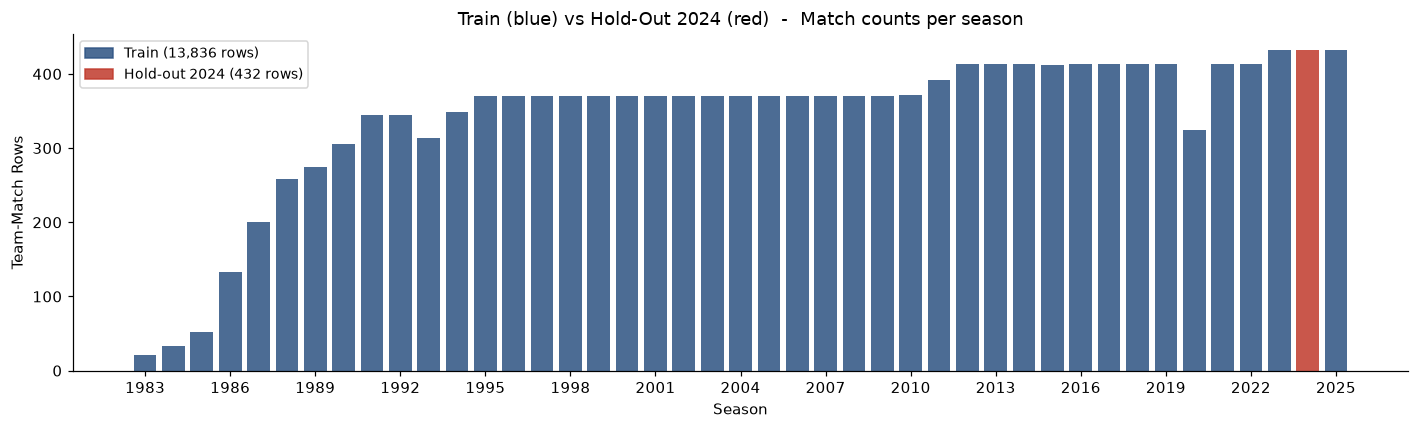

In [ ]:
# Visualise the split 
matches_per_year = feature_table.groupby("year").size()

fig, ax = plt.subplots(figsize=(13, 4))
colors = ["#c0392b" if y == 2024 else "#2c5282" for y in matches_per_year.index]
ax.bar(matches_per_year.index, matches_per_year.values, color=colors, alpha=0.85, width=0.8)
ax.set_xlabel("Season"); ax.set_ylabel("Team-Match Rows")
ax.set_title("Train (blue) vs Hold-Out 2024 (red)  -  Match counts per season")
ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
train_patch = plt.Rectangle((0,0),1,1, color="#2c5282", alpha=0.85, label=f"Train ({len(train_df):,} rows)")
test_patch  = plt.Rectangle((0,0),1,1, color="#c0392b", alpha=0.85, label=f"Hold-out 2024 ({len(test_df):,} rows)")
ax.legend(handles=[train_patch, test_patch], fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/task5_train_test_split.png", dpi=110); plt.show()

### Realistic Prediction Ceiling

AFL match prediction is fundamentally noisy. Even with perfect features and no leakage, literature and industry benchmarks suggest **~65–68% accuracy** for binary win/loss prediction is a realistic ceiling for a well-tuned model. There are several reasons: injuries and last-minute selection changes are unknown at prediction time; weather, umpiring variability, and crowd effects introduce game-day noise that no historical feature can capture; and the competition is deliberately balanced by the draft system, making upsets structurally common. A model predicting 80%+ accuracy on unseen data should be treated as a **red flag for data leakage**, it almost certainly means future information has contaminated the training features (e.g., rolling averages computed without shifting, or a random rather than time-based split). The appropriate benchmark to compare against is the betting market line (~58–60% for informed tipsters), not 100%.

In [25]:
print("=== FEATURE TABLE SHAPE ===")
print(f"  afl_feature_table_v1: {feature_table.shape[0]:,} rows x {feature_table.shape[1]} columns")
print(f"  afl_train_v1:         {len(train_df):,} rows")
print(f"  afl_test_v1:          {len(test_df):,} rows")

=== FEATURE TABLE SHAPE ===
  afl_feature_table_v1: 14,700 rows x 43 columns
  afl_train_v1:         13,836 rows
  afl_test_v1:          432 rows
